In [1]:
from doclayout_yolo import YOLOv10
from dsa.constants import ROOT

/home/ajd/miniconda3/envs/data-snapshot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the pre-trained model
# model = YOLOv10(ROOT / "models/doclayout_yolo_docstructbench_imgsz1024.pt")
# model = YOLOv10(ROOT / "models/doclayout_yolo_doclaynet_imgsz1120_docsynth_pretrain.pt")
model = YOLOv10(ROOT / "models/doclayout_yolo_d4la_imgsz1600_docsynth_pretrain.pt")

# Perform prediction
# IMG_PATH = "../labelstudio_data/dataset_spec/jordanhaus2015finalreport-2.pdf_p004.png"
IMG_PATH = ROOT / "data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png"
res = model.predict(
    IMG_PATH,   # Image to predict
    imgsz=1024,        # Prediction image size
    conf=0.2,          # Confidence threshold
    device="cpu"    # Device to use (e.g., 'cuda:0' or 'cpu')
)
res


image 1/1 /home/ajd/data-snapshot-annotation/data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png: 1024x800 5 ParaTexts, 1 ListText, 3 OtherTexts, 3 Figures, 1 PageNumber, 2857.2ms
Speed: 11.8ms preprocess, 2857.2ms inference, 2.6ms postprocess per image at shape (1, 3, 1024, 800)


[doclayout_yolo.engine.results.Results object with attributes:
 
 boxes: doclayout_yolo.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'DocTitle', 1: 'ParaTitle', 2: 'ParaText', 3: 'ListText', 4: 'RegionTitle', 5: 'Date', 6: 'LetterHead', 7: 'LetterDear', 8: 'LetterSign', 9: 'Question', 10: 'OtherText', 11: 'RegionKV', 12: 'RegionList', 13: 'Abstract', 14: 'Author', 15: 'TableName', 16: 'Table', 17: 'Figure', 18: 'FigureName', 19: 'Equation', 20: 'Reference', 21: 'Footer', 22: 'PageHeader', 23: 'PageFooter', 24: 'Number', 25: 'Catalog', 26: 'PageNumber'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255

In [3]:
res[0].names

{0: 'DocTitle',
 1: 'ParaTitle',
 2: 'ParaText',
 3: 'ListText',
 4: 'RegionTitle',
 5: 'Date',
 6: 'LetterHead',
 7: 'LetterDear',
 8: 'LetterSign',
 9: 'Question',
 10: 'OtherText',
 11: 'RegionKV',
 12: 'RegionList',
 13: 'Abstract',
 14: 'Author',
 15: 'TableName',
 16: 'Table',
 17: 'Figure',
 18: 'FigureName',
 19: 'Equation',
 20: 'Reference',
 21: 'Footer',
 22: 'PageHeader',
 23: 'PageFooter',
 24: 'Number',
 25: 'Catalog',
 26: 'PageNumber'}

In [4]:
res[0].boxes

doclayout_yolo.engine.results.Boxes object with attributes:

cls: tensor([ 2.,  2., 17.,  2., 17.,  2., 10.,  2., 10., 26., 17.,  3., 10.])
conf: tensor([0.9750, 0.9736, 0.9572, 0.9437, 0.9066, 0.8211, 0.7971, 0.7562, 0.6658, 0.6424, 0.6033, 0.5983, 0.4614])
data: tensor([[2.9742e+02, 5.4240e+02, 2.2521e+03, 9.0947e+02, 9.7504e-01, 2.0000e+00],
        [2.9640e+02, 1.6699e+03, 2.2525e+03, 2.0307e+03, 9.7361e-01, 2.0000e+00],
        [2.9793e+02, 9.7580e+02, 2.2466e+03, 1.5991e+03, 9.5723e-01, 1.7000e+01],
        [3.0264e+02, 2.6851e+03, 2.2549e+03, 2.8600e+03, 9.4368e-01, 2.0000e+00],
        [2.9738e+02, 2.1039e+03, 2.1166e+03, 2.6224e+03, 9.0656e-01, 1.7000e+01],
        [2.9591e+02, 4.2950e+02, 9.6485e+02, 4.7190e+02, 8.2107e-01, 2.0000e+00],
        [5.7109e+01, 2.0079e+02, 3.0922e+02, 2.7271e+02, 7.9709e-01, 1.0000e+01],
        [4.7948e+02, 3.1117e+02, 1.3201e+03, 3.5747e+02, 7.5618e-01, 2.0000e+00],
        [7.3205e+02, 1.9497e+02, 1.0270e+03, 2.6201e+02, 6.6575e-01, 1.0000e+01

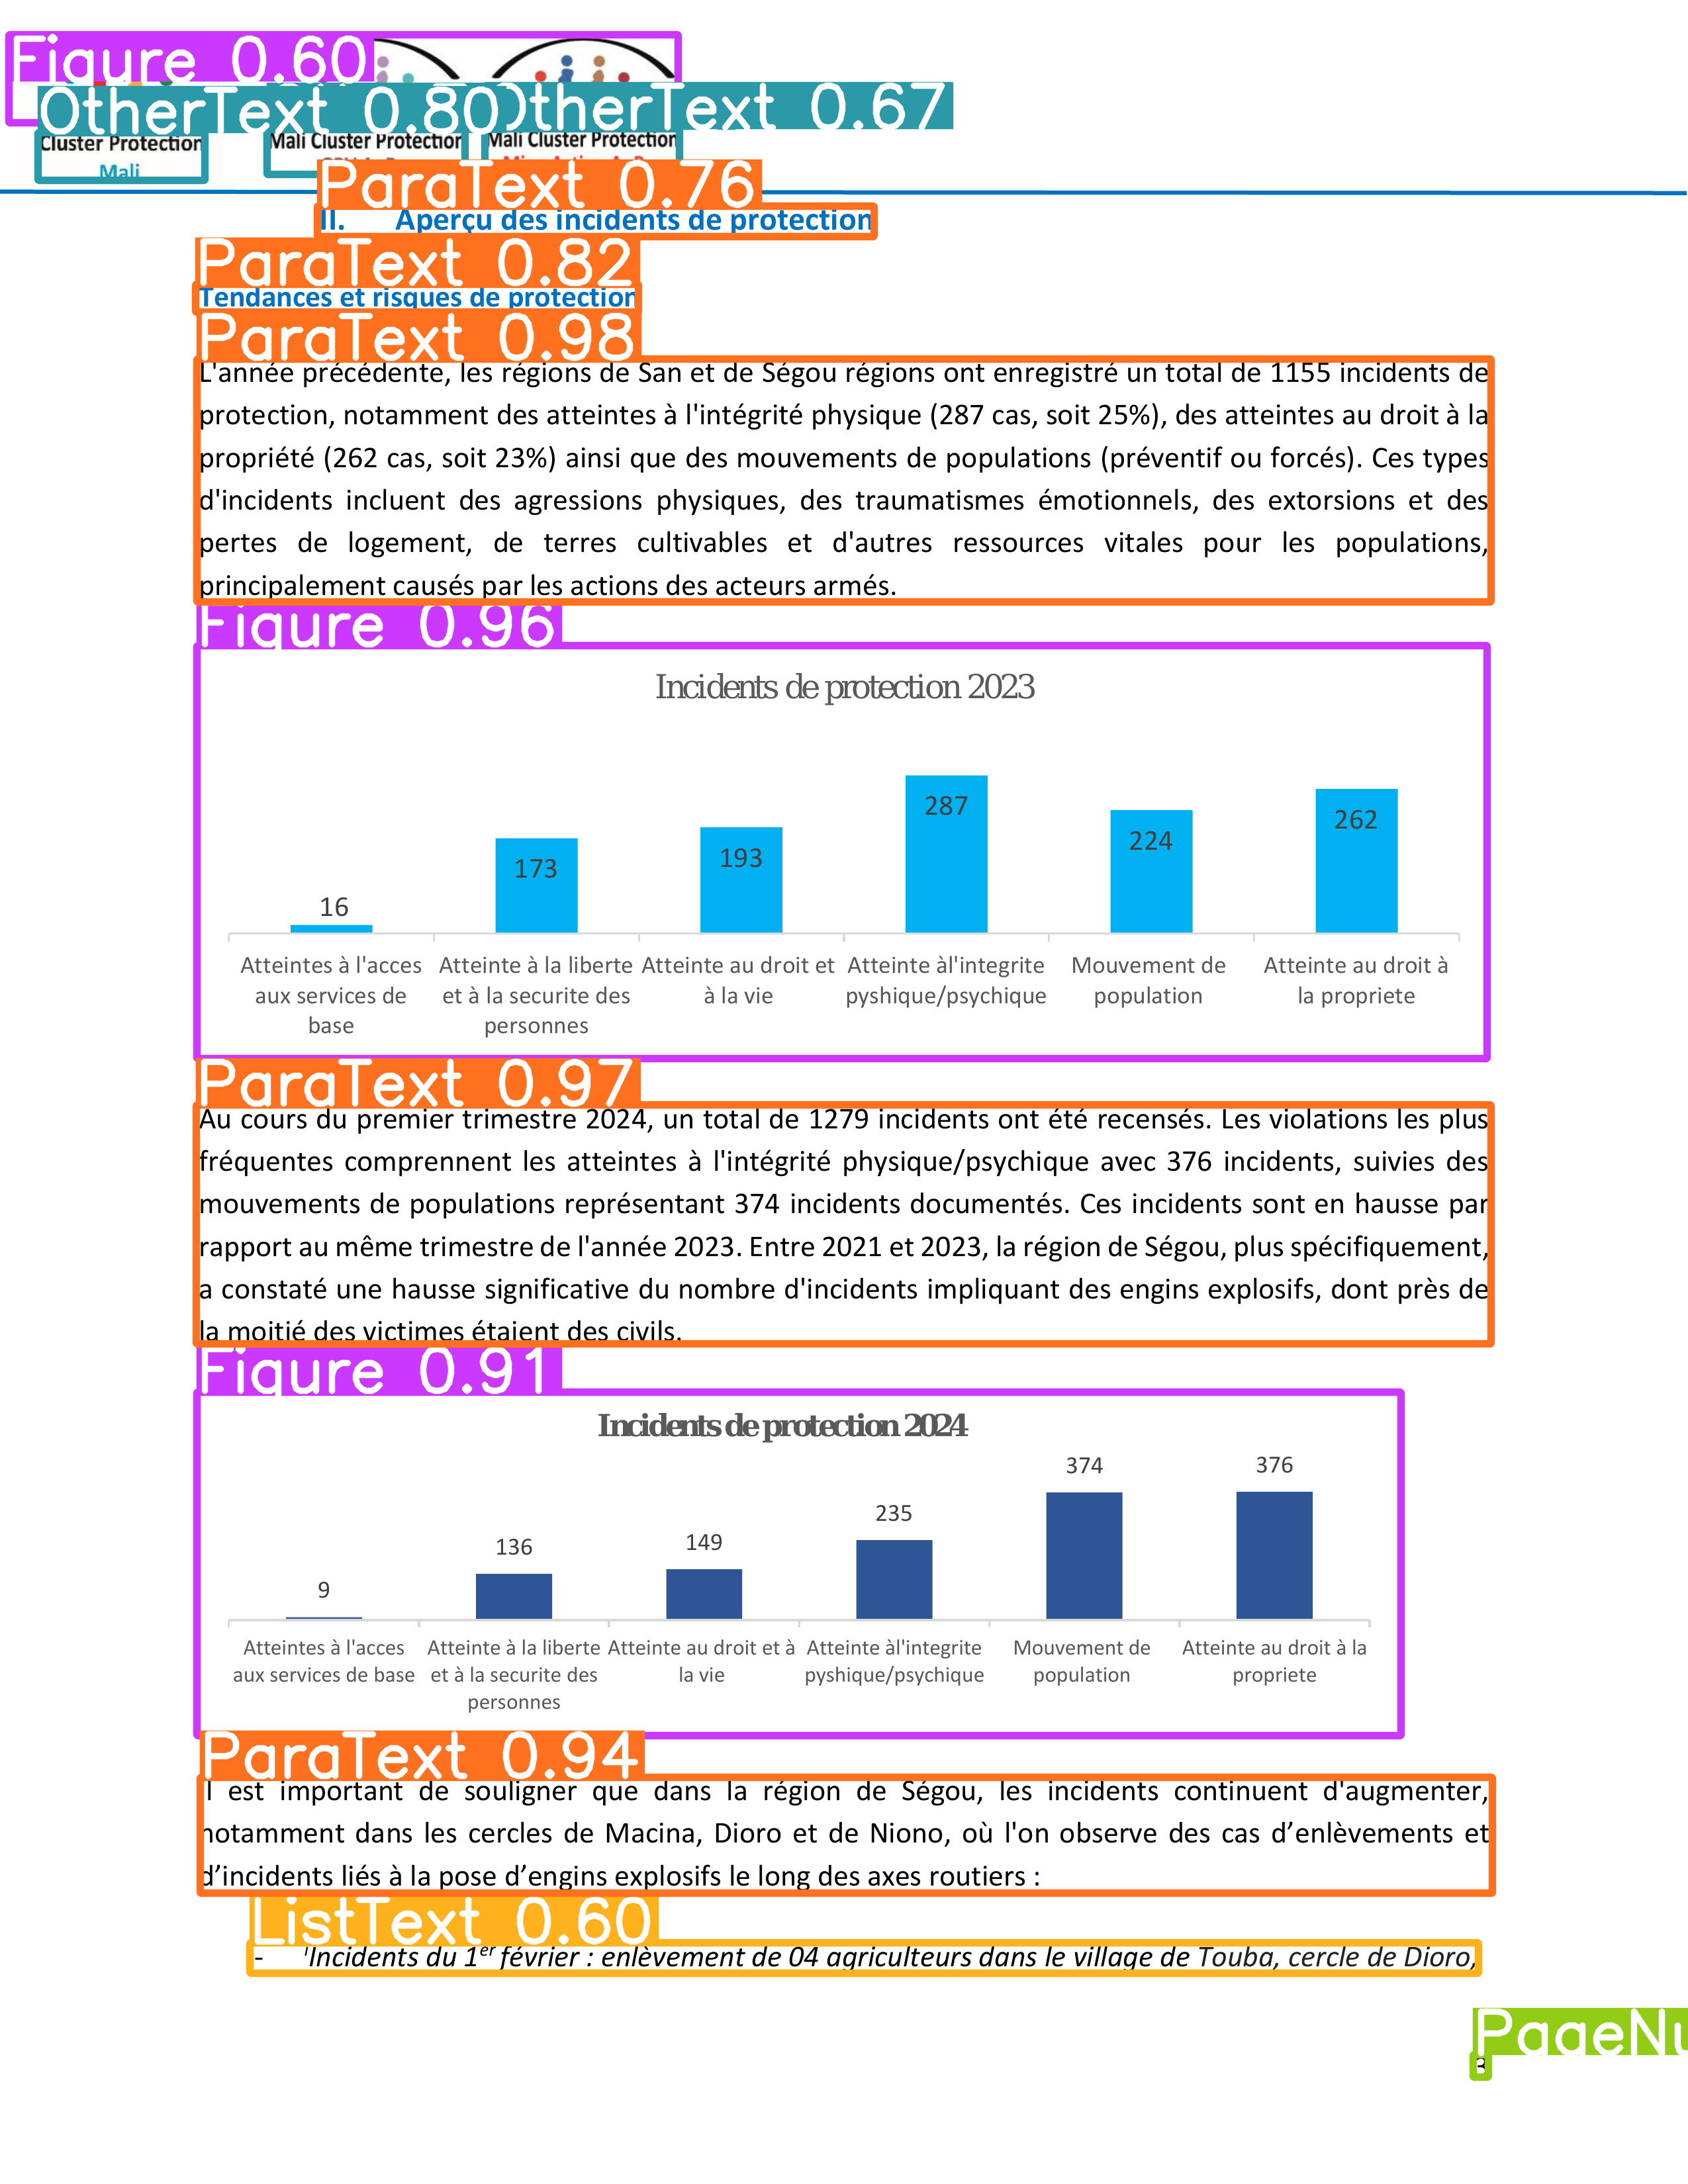

In [5]:
res[0].show()

In [6]:
# # Annotate and save the result
# import cv2
# annotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)
# cv2.imwrite("result.jpg", annotated_frame)